Prediksi Diabetes Menggunakan KNN

1. Install Dependecies 

In [1]:
!pip install imbalanced-learn graphviz matplotlib seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 8.3 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/8.3 MB 8.3 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/8.3 MB 8.3 MB/s eta 0:00:01
   ----- ---------------------------------- 1.0/8.3 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.3 MB 1.2 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.3 MB 894.7 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.3 MB 894.7 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.3 MB 814.1 kB/s eta 0:00:09
   ------- -------------------------------- 1.6/8.3 MB 814.1 kB/s eta 0:00:09
   ---------- ----------------------------- 2.1/8.3 MB 903.1 kB/s eta 0:00:07
   ------------ --------------------------- 2.6/8.3 MB 1.1 MB/s eta 0:00:06
   ------------- -------------------------- 2.9/8.3 MB 1.1 MB/s eta 0:00:05
   ------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Shely\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


2. Import Library

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline

import matplotlib.pyplot as plt

3. Load Dataset

In [4]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


4. Pisahkan fitur dan target

In [17]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Jumlah data:", df.shape)
print("Distribusi kelas:")
print(y.value_counts())

Jumlah data: (768, 9)
Distribusi kelas:
Outcome
0    500
1    268
Name: count, dtype: int64


In [27]:
from collections import Counter

print("Sebelum SMOTE-ENN:")
print(Counter(y_train))

smoteenn = SMOTEENN(random_state=42)
X_res, y_res = smoteenn.fit_resample(X_train, y_train)

print("Sesudah SMOTE-ENN:")
print(Counter(y_res))

Sebelum SMOTE-ENN:
Counter({0: 400, 1: 214})
Sesudah SMOTE-ENN:
Counter({1: 244, 0: 184})


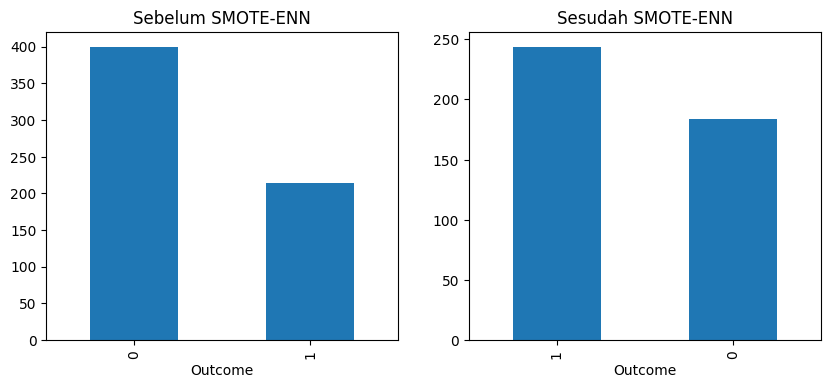

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

before = pd.Series(y_train).value_counts()
after = pd.Series(y_res).value_counts()

fig, ax = plt.subplots(1,2, figsize=(10,4))

before.plot(kind='bar', ax=ax[0])
ax[0].set_title('Sebelum SMOTE-ENN')

after.plot(kind='bar', ax=ax[1])
ax[1].set_title('Sesudah SMOTE-ENN')

plt.show()

5. Split data train/test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

6. Pipeline +pemilihan K terbaik otomatis

In [19]:
k_values = [3, 5, 7, 11, 15, 22]

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc"
}

results = []

for k in k_values:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("smoteenn", SMOTEENN(random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )
    
    results.append({
        "K": k,
        "Accuracy": cv_result["test_accuracy"].mean(),
        "Precision": cv_result["test_precision"].mean(),
        "Recall": cv_result["test_recall"].mean(),
        "F1-Score": cv_result["test_f1"].mean(),
        "AUC": cv_result["test_auc"].mean()
    })

results_df = pd.DataFrame(results)
results_df

,K,Accuracy,Precision,Recall,F1-Score,AUC
0,3,0.721417,0.581395,0.743074,0.651296,0.762140
1,5,0.717980,0.573552,0.770346,0.656008,0.778385
2,7,0.706610,0.559908,0.765801,0.645146,0.791399
3,11,0.719699,0.573096,0.780087,0.659075,0.810070
4,15,0.714913,0.570169,0.761688,0.649671,0.815787
5,22,0.724590,0.579818,0.761472,0.656585,0.818766


7. Ambil K terbaik otomatis

In [20]:
best_k = results_df.loc[results_df["Accuracy"].idxmax(), "K"]

print("K terbaik berdasarkan hasil 10-Fold Cross Validation adalah:", best_k)

K terbaik berdasarkan hasil 10-Fold Cross Validation adalah: 22


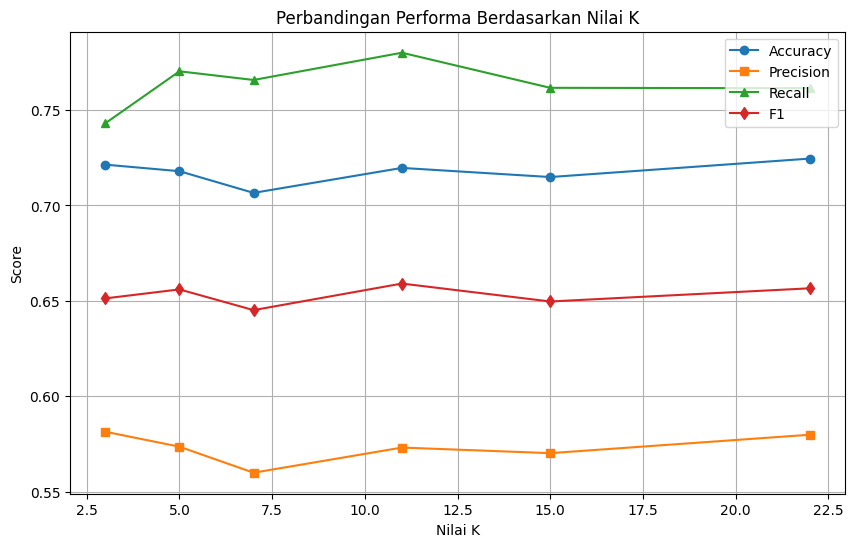

In [29]:
plt.figure(figsize=(10,6))

plt.plot(results_df["K"], results_df["Accuracy"], marker='o', label='Accuracy')
plt.plot(results_df["K"], results_df["Precision"], marker='s', label='Precision')
plt.plot(results_df["K"], results_df["Recall"], marker='^', label='Recall')
plt.plot(results_df["K"], results_df["F1-Score"], marker='d', label='F1')

plt.xlabel("Nilai K")
plt.ylabel("Score")
plt.title("Perbandingan Performa Berdasarkan Nilai K")
plt.legend()
plt.grid()
plt.show()

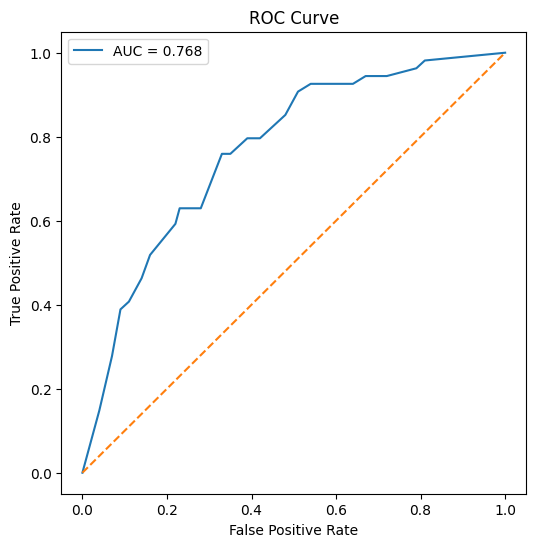

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

8. Visualisasi hasil variasi K

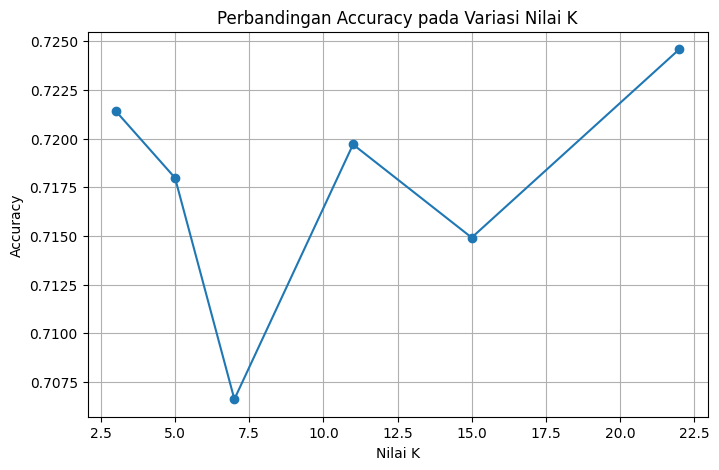

In [21]:
plt.figure(figsize=(8,5))
plt.plot(results_df["K"], results_df["Accuracy"], marker="o")
plt.xlabel("Nilai K")
plt.ylabel("Accuracy")
plt.title("Perbandingan Accuracy pada Variasi Nilai K")
plt.grid(True)
plt.show()

9. Training model akhir dengan K terbaik

In [22]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("smoteenn", SMOTEENN(random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=int(best_k)))
])

final_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smoteenn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


10. Evaluasi akhir data testing

In [23]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== Evaluasi Akhir Data Testing ===")
print("Best K     :", best_k)
print("Accuracy   :", accuracy)
print("Precision  :", precision)
print("Recall     :", recall)
print("F1-Score   :", f1)
print("AUC        :", auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Evaluasi Akhir Data Testing ===
Best K     : 22
Accuracy   : 0.6883116883116883
Precision  : 0.5394736842105263
Recall     : 0.7592592592592593
F1-Score   : 0.6307692307692307
AUC        : 0.7683333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.65      0.73       100
           1       0.54      0.76      0.63        54

    accuracy                           0.69       154
   macro avg       0.69      0.70      0.68       154
weighted avg       0.73      0.69      0.70       154



11. Confusion Matrix

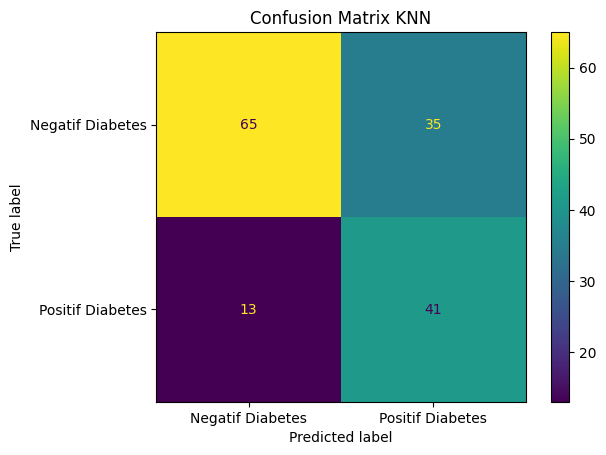

In [24]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negatif Diabetes", "Positif Diabetes"]
)

disp.plot()
plt.title("Confusion Matrix KNN")
plt.show()

12. Sensitivitas fitur

In [25]:
sensitivity_results = []

for feature in X.columns:
    X_train_drop = X_train.drop(feature, axis=1)
    
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("smoteenn", SMOTEENN(random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=int(best_k)))
    ])
    
    cv_result = cross_validate(
        pipeline,
        X_train_drop,
        y_train,
        cv=cv,
        scoring=scoring
    )
    
    sensitivity_results.append({
        "Fitur Dihapus": feature,
        "Accuracy": cv_result["test_accuracy"].mean(),
        "Precision": cv_result["test_precision"].mean(),
        "Recall": cv_result["test_recall"].mean(),
        "F1-Score": cv_result["test_f1"].mean(),
        "AUC": cv_result["test_auc"].mean()
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df = sensitivity_df.sort_values(by="Accuracy")
sensitivity_df

,Fitur Dihapus,Accuracy,Precision,Recall,F1-Score,AUC
1,Glucose,0.651401,0.499767,0.774242,0.606585,0.752289
6,DiabetesPedigreeFunction,0.710021,0.560918,0.775325,0.649145,0.809613
5,BMI,0.719778,0.576800,0.761472,0.653928,0.803923
0,Pregnancies,0.719857,0.570565,0.785498,0.659121,0.809886
7,Age,0.721364,0.579446,0.733333,0.644159,0.804278
4,Insulin,0.724537,0.579990,0.761039,0.656333,0.820027
3,SkinThickness,0.724722,0.586127,0.742857,0.653712,0.811924
2,BloodPressure,0.739371,0.604031,0.728788,0.659148,0.824088


13. Visualisasi sensitivitas fitur

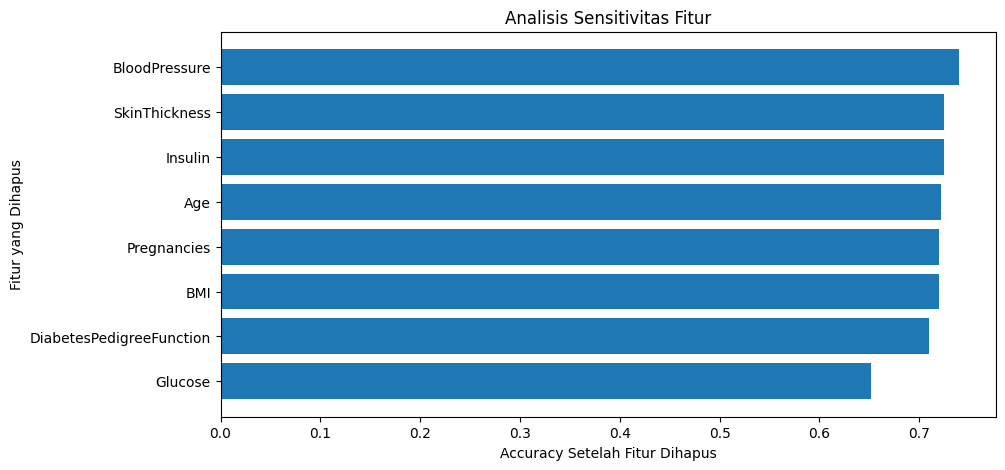

In [26]:
plt.figure(figsize=(10,5))
plt.barh(sensitivity_df["Fitur Dihapus"], sensitivity_df["Accuracy"])
plt.xlabel("Accuracy Setelah Fitur Dihapus")
plt.ylabel("Fitur yang Dihapus")
plt.title("Analisis Sensitivitas Fitur")
plt.show()

In [32]:
baseline_acc = accuracy

feature_importance = []

for col in X.columns:

    X_train_drop = X_train.drop(columns=[col])
    X_test_drop = X_test.drop(columns=[col])

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("smoteenn", SMOTEENN(random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=int(best_k)))
    ])

    model.fit(X_train_drop, y_train)

    pred = model.predict(X_test_drop)

    acc = accuracy_score(y_test, pred)

    feature_importance.append({
        "Feature": col,
        "Penurunan Accuracy": baseline_acc - acc
    })

importance_df = pd.DataFrame(feature_importance)
importance_df.sort_values(
    by="Penurunan Accuracy",
    ascending=False,
    inplace=True
)

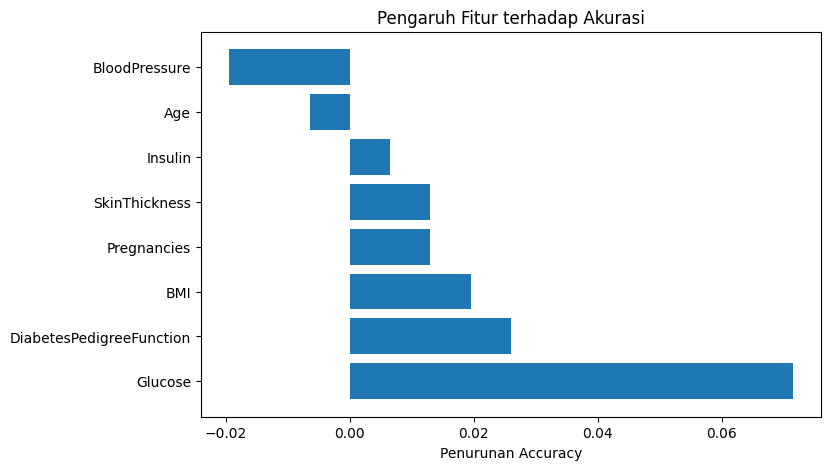

In [33]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Penurunan Accuracy"]
)

plt.title("Pengaruh Fitur terhadap Akurasi")
plt.xlabel("Penurunan Accuracy")

plt.show()

KURANG TEPAT

4. Workflow Visual Interaktif

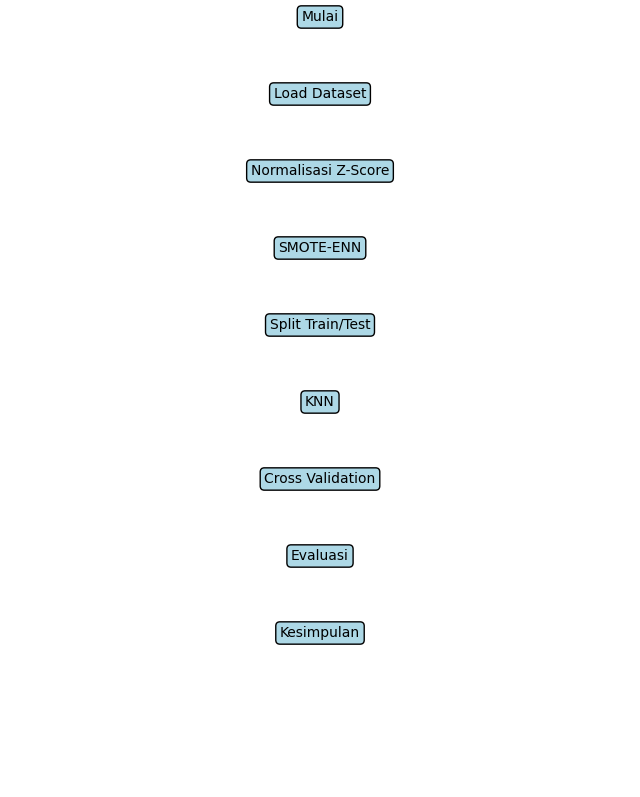

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,10))

ax.axis('off')

steps = [
    "Mulai",
    "Load Dataset",
    "Normalisasi Z-Score",
    "SMOTE-ENN",
    "Split Train/Test",
    "KNN",
    "Cross Validation",
    "Evaluasi",
    "Kesimpulan"
]

for i, step in enumerate(steps):
    ax.text(
        0.5,
        1 - i*0.1,
        step,
        ha='center',
        va='center',
        bbox=dict(boxstyle='round', fc='lightblue')
    )

plt.show()

5. Preprocessing Data

In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Penyeimbangan kelas
smote_enn = SMOTEENN(random_state=42)
X_res, y_res = smote_enn.fit_resample(X_scaled, y)

6. Split Data Train/Test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

7. KNN Model & Cross-Validation

In [10]:
k_values = [3,5,7,11,15,22]
cv_results = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train, y_train, cv=kf, scoring='accuracy')
    cv_results.append((k, cv_score.mean()))

results_df = pd.DataFrame(cv_results, columns=['K', 'CV_Accuracy'])
results_df

,K,CV_Accuracy
0,3,0.957934
1,5,0.932668
2,7,0.924291
3,11,0.928413
4,15,0.915691
5,22,0.909530


8. Training Model KNN Terbaik (K=22)

In [11]:
best_k = 22
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

y_pred = knn_best.predict(X_test)
y_proba = knn_best.predict_proba(X_test)[:,1]

9. Evaluasi Mode 

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("AUC:", auc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.9416666666666667
Precision: 0.9322033898305084
Recall: 0.9482758620689655
F1-Score: 0.9401709401709402
AUC: 0.989710789766407
Confusion Matrix:
 [[58  4]
 [ 3 55]]


10. Visualisasi Evaluasi

a. Confusion Matrix

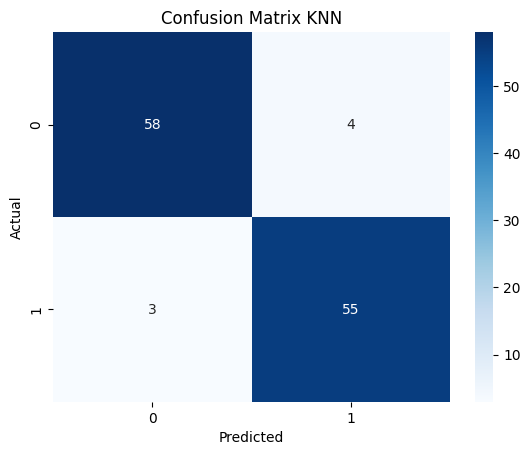

In [13]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

b. ROC Curve

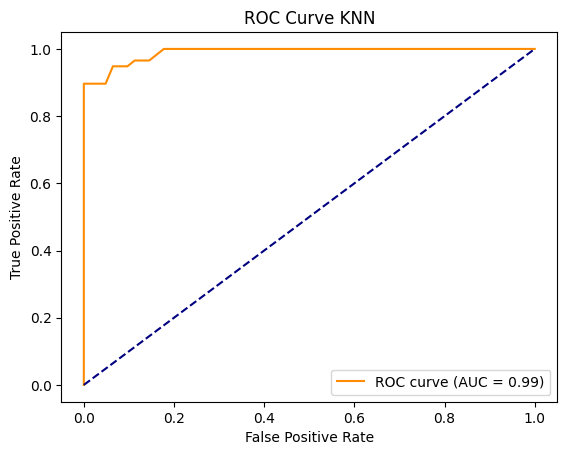

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (AUC = %0.2f)' % auc)
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve KNN')
plt.legend(loc='lower right')
plt.show()

c. Akurasi vs K

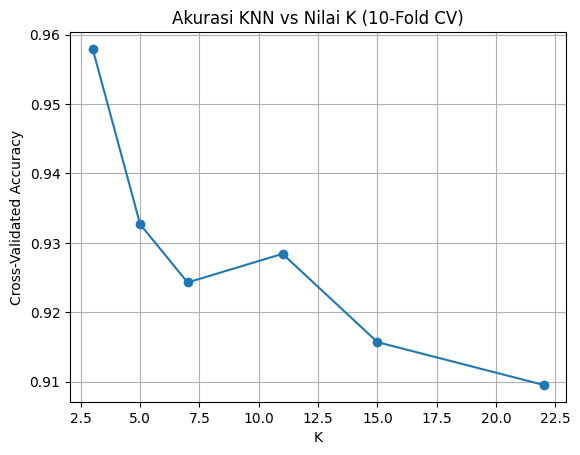

In [15]:
plt.plot(results_df['K'], results_df['CV_Accuracy'], marker='o')
plt.title('Akurasi KNN vs Nilai K (10-Fold CV)')
plt.xlabel('K')
plt.ylabel('Cross-Validated Accuracy')
plt.grid(True)
plt.show()